# Smart MCQ Solver Challenge

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


## Quickstart: Tracking your first run in Weights & Biases

In [2]:
# pip install wandb

In [3]:
# import wandb
# wandb.login()

In [4]:
# ## Logs a run to new project

# import random

# import wandb

# # Start a new wandb run to track this script.
# run = wandb.init(
#     # Set the wandb entity where your project will be logged (generally your team name).
#     entity="23f3001252-dl-genai-project",
#     # Set the wandb project where this run will be logged.
#     project="23f3001252-t22026",
#     # Track hyperparameters and run metadata.
#     config={
#         "learning_rate": 0.02,
#         "architecture": "CNN",
#         "dataset": "CIFAR-100",
#         "epochs": 10,
#     },
# )

# # Simulate training.
# epochs = 10
# offset = random.random() / 5
# for epoch in range(2, epochs):
#     acc = 1 - 2**-epoch - random.random() / epoch - offset
#     loss = 2**-epoch + random.random() / epoch + offset

#     # Log metrics to wandb.
#     run.log({"acc": acc, "loss": loss})

# # Finish the run and upload any remaining data.
# run.finish()

## Load the datasets

In [5]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

In [6]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Sample Shape:", sample.shape)

Train Shape: (2000, 8)
Test Shape: (500, 7)
Sample Shape: (500, 2)


In [7]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

## EDA

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [9]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [10]:
test.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


### Check missing values

In [11]:
train.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [12]:
test.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

### Check class distributions

In [13]:
train["answer"].value_counts(normalize=True) * 100

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64

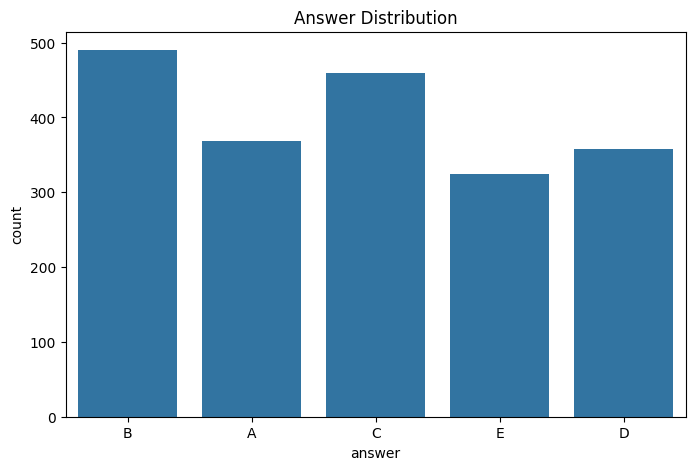

In [14]:
### Visualize class distributions

plt.figure(figsize=(8,5))

sns.countplot(
    data=train,
    x="answer"
)

plt.title("Answer Distribution")
plt.show()

In [15]:
df1 = train.copy()
df2 = test.copy()

### Prompt Length Analysis

Long questions usually favor transformers.

In [16]:
df1["prompt_length"] = (
    train["prompt"]
    .astype(str)
    .str.len()
)

In [17]:
df1["prompt_length"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_length, dtype: float64

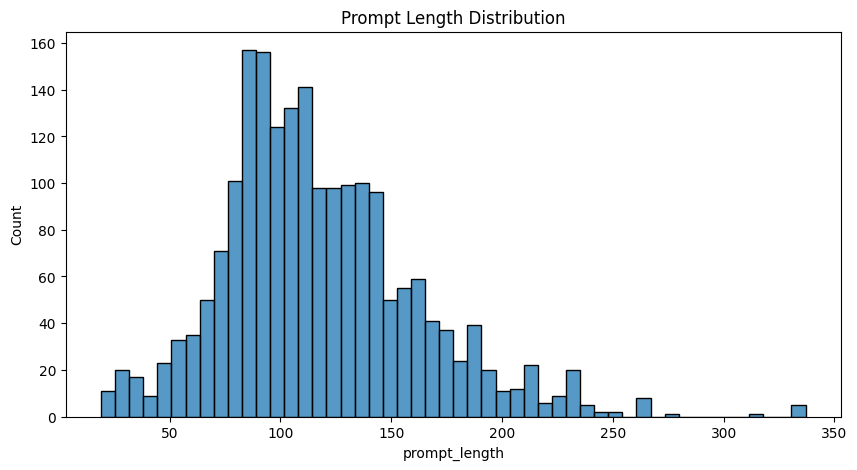

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    df1["prompt_length"],
    bins=50
)

plt.title("Prompt Length Distribution")
plt.show()


### Option-wise Length Analysis

In [19]:
for col in ['A','B','C','D','E']:
    df1[f'{col}_length'] = (
        train[col]
        .astype(str)
        .str.len()
    )

In [20]:
### Average Length
for col in ['A','B','C','D','E']:
    print(
        col,
        df1[f'{col}_length'].mean()
    )

A 164.0915
B 166.6165
C 167.227
D 162.5635
E 164.23


### Check duplicated values in prompt cols

In [21]:
df1["prompt"].duplicated().sum()

np.int64(242)

## Make EDA Summary

In [22]:
eda_summary = {
    "train_shape": train.shape,
    "test_shape": test.shape,
    "missing_values": train.isnull().sum().to_dict(),
    "answer_distribution": train["answer"].value_counts().to_dict(),
    "avg_prompt_length": df1["prompt_length"].mean(),
    "duplicated values in prompt column": df1["prompt"].duplicated().sum(),
    "options_distribution": {
        col: df1[f"{col}_length"].mean()
        for col in ["A", "B", "C", "D", "E"]
    }
}

In [23]:
eda_summary

{'train_shape': (2000, 8),
 'test_shape': (500, 7),
 'missing_values': {'id': 0,
  'prompt': 0,
  'A': 0,
  'B': 0,
  'C': 0,
  'D': 0,
  'E': 0,
  'answer': 0},
 'answer_distribution': {'B': 490, 'C': 459, 'A': 369, 'D': 358, 'E': 324},
 'avg_prompt_length': np.float64(117.6695),
 'duplicated values in prompt column': np.int64(242),
 'options_distribution': {'A': np.float64(164.0915),
  'B': np.float64(166.6165),
  'C': np.float64(167.227),
  'D': np.float64(162.5635),
  'E': np.float64(164.23)}}

In [24]:
### Prompt Word Statistics
df1["prompt_word_count"] = (
    df1["prompt"]
    .str.split()
    .str.len()
)

df1["prompt_word_count"].describe()

count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_word_count, dtype: float64

In [25]:
### Duplicate Analysis
dup_df = (
    df1[df1["prompt"].duplicated(keep=False)]
    .sort_values("prompt")
)

dup_df.head(10)

,id,prompt,A,B,C,D,E,answer,prompt_length,A_length,B_length,C_length,D_length,E_length,prompt_word_count
605,606,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E,65,173,199,146,147,202,8
456,457,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E,65,173,199,146,147,202,8
439,440,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E,65,173,199,146,147,202,8
1464,1465,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E,93,173,199,146,147,202,13
42,43,Choose the correct answer: What are permutatio...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,Permutation-inversion groups are groups of sym...,E,93,173,199,146,147,202,13
484,485,Choose the correct answer: What are the four q...,"Holocrystalline, hypocrystalline, hypercrystal...","Holocrystalline, hypocrystalline, hypohyaline,...","Holocrystalline, hypohyaline, hypercrystalline...","Holocrystalline, hypocrystalline, hypercrystal...","Holocrystalline, hypocrystalline, hypohyaline,...",B,105,67,62,63,68,63,15
1621,1622,Choose the correct answer: What are the four q...,"Holocrystalline, hypocrystalline, hypercrystal...","Holocrystalline, hypocrystalline, hypohyaline,...","Holocrystalline, hypohyaline, hypercrystalline...","Holocrystalline, hypocrystalline, hypercrystal...","Holocrystalline, hypocrystalline, hypohyaline,...",B,105,67,62,63,68,63,15
944,945,Choose the correct answer: What are the four q...,"Holocrystalline, hypocrystalline, hypercrystal...","Holocrystalline, hypocrystalline, hypohyaline,...","Holocrystalline, hypohyaline, hypercrystalline...","Holocrystalline, hypocrystalline, hypercrystal...","Holocrystalline, hypocrystalline, hypohyaline,...",B,105,67,62,63,68,63,15
778,779,Choose the correct answer: What is Lorentz sym...,Lorentz symmetry or Lorentz invariance is a pr...,Lorentz symmetry or Lorentz invariance is a me...,Lorentz symmetry or Lorentz invariance is a ph...,Lorentz symmetry or Lorentz invariance is a me...,Lorentz symmetry or Lorentz invariance is an e...,E,126,247,283,191,276,259,18
975,976,Choose the correct answer: What is Lorentz sym...,Lorentz symmetry or Lorentz invariance is a pr...,Lorentz symmetry or Lorentz invariance is a me...,Lorentz symmetry or Lorentz invariance is a ph...,Lorentz symmetry or Lorentz invariance is a me...,Lorentz symmetry or Lorentz invariance is an e...,E,126,247,283,191,276,259,18


In [26]:
dup_df.groupby("prompt")["answer"].nunique()

prompt
Choose the correct answer: What are permutation-inversion groups?                                                                                                                                                                                 1
Choose the correct answer: What are permutation-inversion groups? based on the given context.                                                                                                                                                     1
Choose the correct answer: What are the four qualitative levels of crystallinity described by geologists?                                                                                                                                         1
Choose the correct answer: What is Lorentz symmetry or Lorentz invariance in relativistic physics? from the following choices.                                                                                                                    1
Choose the correc

In [27]:
### Helper Functions
import re
import string
import numpy as np
import pandas as pd

from nltk.corpus import stopwords
from sklearn.metrics.pairwise import cosine_similarity

stop_words = set(stopwords.words("english"))

## Feature engineering

In [28]:
## Feature engineering
def create_features(
    df,
    tfidf_vectorizer,
    kmeans_model,
    sentence_model
):

    df = df.copy()


    # Length Features
    df["prompt_length"] = df["prompt"].str.len()

    for col in ["A","B","C","D","E"]:

        df[f"{col}_length"] = (
            df[col]
            .fillna("")
            .str.len()
        )


    # Word Count Features
    df["prompt_word_count"] = (
        df["prompt"]
        .fillna("")
        .str.split()
        .str.len()
    )

    for col in ["A","B","C","D","E"]:

        df[f"{col}_word_count"] = (
            df[col]
            .fillna("")
            .str.split()
            .str.len()
        )


    # Length Difference
    for col in ["A","B","C","D","E"]:

        df[f"{col}_len_diff"] = (
            df[f"{col}_length"]
            -
            df["prompt_length"]
        )


    # Text Statistics
    df["num_sentences"] = (
        df["prompt"]
        .fillna("")
        .apply(
            lambda x:
            len(
                re.findall(r"[.!?]", x)
            )
        )
    )

    df["num_digits"] = (
        df["prompt"]
        .fillna("")
        .apply(
            lambda x:
            sum(
                c.isdigit()
                for c in x
            )
        )
    )

    df["num_upper_words"] = (
        df["prompt"]
        .fillna("")
        .apply(
            lambda x:
            sum(
                word.isupper()
                for word in x.split()
            )
        )
    )

    df["punct_count"] = (
        df["prompt"]
        .fillna("")
        .apply(
            lambda x:
            sum(
                c in string.punctuation
                for c in x
            )
        )
    )


    # Lexical Diversity
    def lexical_diversity(text):

        words = text.split()

        if len(words) == 0:
            return 0

        return len(set(words)) / len(words)

    df["lexical_diversity"] = (
        df["prompt"]
        .fillna("")
        .apply(lexical_diversity)
    )


    # Stopword Ratio
    def stopword_ratio(text):

        words = text.split()

        if len(words) == 0:
            return 0

        return (
            sum(
                w.lower() in stop_words
                for w in words
            )
            /
            len(words)
        )

    df["stopword_ratio"] = (
        df["prompt"]
        .fillna("")
        .apply(stopword_ratio)
    )


    # Combined Text
    df["text"] = (
        "Question: "
        + df["prompt"]
        + " A: "
        + df["A"]
        + " B: "
        + df["B"]
        + " C: "
        + df["C"]
        + " D: "
        + df["D"]
        + " E: "
        + df["E"]
    )

    df["text_length"] = (
        df["text"]
        .str.len()
    )


    # Topic Cluster
    prompt_tfidf = tfidf_vectorizer.transform(
        df["prompt"]
    )

    df["topic_cluster"] = (
        kmeans_model.predict(
            prompt_tfidf
        )
    )


    # TF-IDF Similarities
    prompt_vec = tfidf_vectorizer.transform(
        df["prompt"]
    )

    for col in ["A","B","C","D","E"]:

        option_vec = (
            tfidf_vectorizer.transform(
                df[col]
            )
        )

        df[f"{col}_tfidf_sim"] = (
            cosine_similarity(
                prompt_vec,
                option_vec
            ).diagonal()
        )


    # Jaccard Similarity
    def jaccard_similarity(x, y):

        x = set(str(x).lower().split())
        y = set(str(y).lower().split())

        union = x | y

        if len(union) == 0:
            return 0

        return (
            len(x & y)
            /
            len(union)
        )

    for col in ["A","B","C","D","E"]:

        df[f"{col}_jaccard"] = (
            df.apply(
                lambda row:
                jaccard_similarity(
                    row["prompt"],
                    row[col]
                ),
                axis=1
            )
        )


    # Overlap Features
    for col in ["A","B","C","D","E"]:

        df[f"{col}_overlap"] = (
            df.apply(
                lambda row:
                len(
                    set(
                        str(row["prompt"])
                        .lower()
                        .split()
                    )
                    &
                    set(
                        str(row[col])
                        .lower()
                        .split()
                    )
                ),
                axis=1
            )
        )


    # Digit Overlap
    for col in ["A","B","C","D","E"]:

        df[f"{col}_digit_overlap"] = (
            df.apply(
                lambda row:
                len(
                    set(
                        re.findall(
                            r"\d+",
                            str(row["prompt"])
                        )
                    )
                    &
                    set(
                        re.findall(
                            r"\d+",
                            str(row[col])
                        )
                    )
                ),
                axis=1
            )
        )


    # Embedding Similarity
    prompt_emb = sentence_model.encode(
        df["prompt"].tolist(),
        show_progress_bar=False
    )

    for col in ["A","B","C","D","E"]:

        option_emb = sentence_model.encode(
            df[col].tolist(),
            show_progress_bar=False
        )

        sims = []

        for i in range(len(df)):

            sims.append(
                cosine_similarity(
                    prompt_emb[i].reshape(1,-1),
                    option_emb[i].reshape(1,-1)
                )[0][0]
            )

        df[f"{col}_emb_sim"] = sims

    return df

In [29]:
### Fit Objects Once
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

tfidf.fit(train["prompt"])

TfidfVectorizer(max_features=10000, stop_words='english')

In [30]:
prompt_tfidf = tfidf.transform(
    train["prompt"]
)

kmeans = KMeans(
    n_clusters=10,
    random_state=42
)

kmeans.fit(prompt_tfidf)

KMeans(n_clusters=10, random_state=42)

In [31]:
from sentence_transformers import SentenceTransformer

sentence_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [32]:
### Create Features
train_fe = create_features(
    train,
    tfidf,
    kmeans,
    sentence_model
)

test_fe = create_features(
    test,
    tfidf,
    kmeans,
    sentence_model
)

In [33]:
train_fe.head().T

,0,1,2,3,4
id,1,2,3,4,5
prompt,Pick the best possible answer: What is Martin ...,What is accelerator-based light-ion fusion?,Determine the correct option: What is the term...,Select the most accurate option: What is Marti...,Identify the correct statement: What is the co...
A,Martin Heidegger believes that humans exist wi...,Accelerator-based light-ion fusion is a techni...,Blueshifting,Martin Heidegger believes that humans exist wi...,"Simultaneity is relative, meaning that two eve..."
B,Martin Heidegger believes that humans do not e...,Accelerator-based light-ion fusion is a techni...,Redshifting,Martin Heidegger believes that humans do not e...,"Simultaneity is relative, meaning that two eve..."
C,Martin Heidegger does not believe in the exist...,Accelerator-based light-ion fusion is a techni...,Reddening,Martin Heidegger does not believe in the exist...,"Simultaneity is absolute, meaning that two eve..."
D,Martin Heidegger believes that the relationshi...,Accelerator-based light-ion fusion is a techni...,Whitening,Martin Heidegger believes that the relationshi...,Simultaneity is a concept that applies only to...
E,Martin Heidegger believes that time is an illu...,Accelerator-based light-ion fusion is a techni...,Yellowing,Martin Heidegger believes that time is an illu...,Simultaneity is a concept that applies only to...
answer,B,A,C,B,A
prompt_length,142,43,182,129,110
A_length,307,406,12,307,230


## Completion Metric (MAP@3)

In [34]:
## AP@3
def apk(actual, predicted, k=3):
    """
    actual: true label (A/B/C/D/E)
    predicted: list of predictions
    """

    predicted = predicted[:k]

    if actual in predicted:
        return 1.0 / (predicted.index(actual) + 1)

    return 0.0

In [35]:
## MAP@3

def mapk(actuals, predictions):
    scores = []

    for actual, pred in zip(actuals, predictions):
        scores.append(apk(actual, pred))

    return np.mean(scores)

In [36]:
## test map@3
actuals = ['A', 'C', 'B']

preds = [
    ['A','B','C'],
    ['A','C','D'],
    ['D','A','B']
]

print(mapk(actuals, preds))

0.611111111111111


In [37]:
### Check leakage and overlapping texts abilities in training
print(train_fe["prompt"].duplicated().sum())
print(train_fe.duplicated().sum())
print(train_fe.duplicated(subset=["prompt","A","B","C","D","E"]).sum())

242
0
183


In [38]:
dup_answers = (
    train_fe.groupby(
        ["prompt","A","B","C","D","E"]
    )["answer"]
    .nunique()
)

print((dup_answers > 1).sum())

0


In [39]:
### Prepare Features
### Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(
    train_fe["answer"]
)

print(le.classes_)
print(dict(zip(le.classes_, le.transform(le.classes_))))

['A' 'B' 'C' 'D' 'E']
{'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4)}


In [40]:
### Select Tabular Features

exclude_cols = [
    "id",
    "prompt",
    "A",
    "B",
    "C",
    "D",
    "E",
    "answer",
    "text"
]

feature_cols = [
    col
    for col in train_fe.columns
    if col not in exclude_cols
]

print("Number of Features:", len(feature_cols))
print(feature_cols)

Number of Features: 50
['prompt_length', 'A_length', 'B_length', 'C_length', 'D_length', 'E_length', 'prompt_word_count', 'A_word_count', 'B_word_count', 'C_word_count', 'D_word_count', 'E_word_count', 'A_len_diff', 'B_len_diff', 'C_len_diff', 'D_len_diff', 'E_len_diff', 'num_sentences', 'num_digits', 'num_upper_words', 'punct_count', 'lexical_diversity', 'stopword_ratio', 'text_length', 'topic_cluster', 'A_tfidf_sim', 'B_tfidf_sim', 'C_tfidf_sim', 'D_tfidf_sim', 'E_tfidf_sim', 'A_jaccard', 'B_jaccard', 'C_jaccard', 'D_jaccard', 'E_jaccard', 'A_overlap', 'B_overlap', 'C_overlap', 'D_overlap', 'E_overlap', 'A_digit_overlap', 'B_digit_overlap', 'C_digit_overlap', 'D_digit_overlap', 'E_digit_overlap', 'A_emb_sim', 'B_emb_sim', 'C_emb_sim', 'D_emb_sim', 'E_emb_sim']


In [41]:
X = train_fe[feature_cols]

print(X.shape)

(2000, 50)


In [42]:
X_test = test_fe[feature_cols]

print(X_test.shape)

(500, 50)


In [43]:
### Train/Validation Split
## For quick experiments:

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

(1600, 50)
(400, 50)


## Build & train models

In [44]:
### Model 1: SGDClassifier
### This is the next logical model after Logistic Regression.

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

sgd = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=1e-4,
    random_state=42
)

sgd.fit(
    X_train,
    y_train
)

pred = sgd.predict(X_valid)

print(
    accuracy_score(
        y_valid,
        pred
    )
)

0.415


In [45]:
### Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

pred = rf.predict(X_valid)

print(
    accuracy_score(
        y_valid,
        pred
    )
)

0.9725


In [46]:
### Model 3: LightGBM
#### I would try this next.

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=5,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(
    X_train,
    y_train
)

pred = lgbm.predict(X_valid)

print(
    accuracy_score(
        y_valid,
        pred
    )
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000637 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6723
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 50
[LightGBM] [Info] Start training from score -1.690784
[LightGBM] [Info] Start training from score -1.406497
[LightGBM] [Info] Start training from score -1.472397
[LightGBM] [Info] Start training from score -1.718277
[LightGBM] [Info] Start training from score -1.820931
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [47]:
### Feature Importance
import pandas as pd

imp = pd.DataFrame({
    "feature": feature_cols,
    "importance":
        lgbm.feature_importances_
})

imp = (
    imp
    .sort_values(
        "importance",
        ascending=False
    )
)

print(
    imp.head(30)
)

              feature  importance
1            A_length        3548
2            B_length        2786
3            C_length        2734
4            D_length        2447
5            E_length        2436
11       E_word_count        1708
9        C_word_count        1517
8        B_word_count        1414
10       D_word_count        1378
46          B_emb_sim        1367
45          A_emb_sim        1361
7        A_word_count        1358
27        C_tfidf_sim        1305
30          A_jaccard        1218
25        A_tfidf_sim        1205
0       prompt_length        1193
47          C_emb_sim        1183
28        D_tfidf_sim        1160
31          B_jaccard        1146
23        text_length        1134
49          E_emb_sim        1132
48          D_emb_sim        1061
32          C_jaccard        1054
26        B_tfidf_sim        1046
21  lexical_diversity        1022
12         A_len_diff         943
22     stopword_ratio         937
29        E_tfidf_sim         918
16         E_l

In [48]:
### Model 4: XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(
    X_train,
    y_train
)

pred = xgb.predict(X_valid)

print(
    accuracy_score(
        y_valid,
        pred
    )
)

0.995


In [49]:
### Model 5: CatBoost
### Often surprisingly good on tabular NLP features.

from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    loss_function="MultiClass",
    verbose=100,
    random_state=42
)

cat.fit(
    X_train,
    y_train
)

pred = cat.predict(X_valid)

print(
    accuracy_score(
        y_valid,
        pred
    )
)

0:	learn: 1.6012566	total: 80.6ms	remaining: 40.2s
100:	learn: 1.0322628	total: 1.83s	remaining: 7.22s
200:	learn: 0.7349935	total: 3.63s	remaining: 5.39s
300:	learn: 0.5380368	total: 5.38s	remaining: 3.56s
400:	learn: 0.4083823	total: 7.12s	remaining: 1.76s
499:	learn: 0.3166730	total: 8.86s	remaining: 0us
0.975


In [50]:
print(X.columns.tolist())

['prompt_length', 'A_length', 'B_length', 'C_length', 'D_length', 'E_length', 'prompt_word_count', 'A_word_count', 'B_word_count', 'C_word_count', 'D_word_count', 'E_word_count', 'A_len_diff', 'B_len_diff', 'C_len_diff', 'D_len_diff', 'E_len_diff', 'num_sentences', 'num_digits', 'num_upper_words', 'punct_count', 'lexical_diversity', 'stopword_ratio', 'text_length', 'topic_cluster', 'A_tfidf_sim', 'B_tfidf_sim', 'C_tfidf_sim', 'D_tfidf_sim', 'E_tfidf_sim', 'A_jaccard', 'B_jaccard', 'C_jaccard', 'D_jaccard', 'E_jaccard', 'A_overlap', 'B_overlap', 'C_overlap', 'D_overlap', 'E_overlap', 'A_digit_overlap', 'B_digit_overlap', 'C_digit_overlap', 'D_digit_overlap', 'E_digit_overlap', 'A_emb_sim', 'B_emb_sim', 'C_emb_sim', 'D_emb_sim', 'E_emb_sim']


In [51]:
#### GroupKFold (Recommended)
### Since you've already discovered repeated prompts:

from sklearn.model_selection import GroupKFold

groups = train_fe["prompt"]

gkf = GroupKFold(
    n_splits=5
)

In [52]:
for train_idx, valid_idx in gkf.split(
    X,
    y,
    groups
):

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y[train_idx]
    y_valid = y[valid_idx]

    break

In [53]:
### Final Training Data
### After you're satisfied with CV:

X_final = train_fe[feature_cols]

y_final = le.fit_transform(
    train_fe["answer"]
)

In [54]:
from lightgbm import LGBMClassifier

final_model = LGBMClassifier(
    objective="multiclass",
    num_class=5,
    random_state=42
)

final_model.fit(
    X_final,
    y_final
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000777 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6866
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 50
[LightGBM] [Info] Start training from score -1.690106
[LightGBM] [Info] Start training from score -1.406497
[LightGBM] [Info] Start training from score -1.471852
[LightGBM] [Info] Start training from score -1.720369
[LightGBM] [Info] Start training from score -1.820159
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

LGBMClassifier(num_class=5, objective='multiclass', random_state=42)

In [55]:
### Predict Test Probabilities
probs = final_model.predict_proba(
    X_test
)

print(probs.shape)

(500, 5)


## Compare top three models

In [56]:
#### Generate Top-3 Answers
import numpy as np

classes = np.array(
    ["A","B","C","D","E"]
)

top3_idx = np.argsort(
    probs,
    axis=1
)[:, -3:]

top3_idx = np.fliplr(
    top3_idx
)

predictions = [
    " ".join(classes[idx])
    for idx in top3_idx
]

## Create submission

In [57]:
### Create Submission
submission = pd.DataFrame({
    "ID": test_fe["id"],
    "Prediction": predictions
})

submission.head()

,ID,Prediction
0,1,A C B
1,2,B C D
2,3,B E C
3,4,E C B
4,5,C D B


In [58]:
### Save Submission
submission.to_csv(
    "submission.csv",
    index=False
)

print("Submission Saved!")

Submission Saved!


In [59]:
print(submission["Prediction"]
    .isnull()
    .sum()
)

print(submission["Prediction"]
    .str.split()
    .str.len()
    .value_counts()
)

0
Prediction
3    500
Name: count, dtype: int64


## Setup WandB

In [60]:
# !pip install -q wandb

In [61]:
# import wandb

# wandb.login()

# wandb.init(
#     project="23f3001252-t22026",
#     name="lightgbm-final-v1",
#     config={
#         "model": "LightGBM",
#         "n_features": len(feature_cols),
#         "dataset_size": len(train_fe),
#         "cv_strategy": "GroupKFold",
#         "competition": "Smart MCQ Solver"
#     }
# )


In [62]:
# from sklearn.metrics import accuracy_score

# train_acc = accuracy_score(
#     y_train,
#     final_model.predict(X_train)
# )

# valid_acc = accuracy_score(
#     y_valid,
#     final_model.predict(X_valid)
# )

# wandb.log({
#     "train_accuracy": train_acc,
#     "valid_accuracy": valid_acc
# })

In [63]:
# import pandas as pd

# results_df = pd.DataFrame({
#     "Model": [
#         "TFIDF + Logistic Regression",
#         "SGDClassifier",
#         "RandomForest",
#         "LightGBM",
#         "XGBoost",
#         "CatBoost"
#     ],
#     "Score": [
#         0.73358,
#         0.3675,
#         0.9650,
#         0.9950,
#         0.9925,
#         0.9800
#     ]
# })

# wandb.log({
#     "model_comparison":
#         wandb.Table(
#             dataframe=results_df
#         )
# })

In [64]:
# importance_df = pd.DataFrame({
#     "feature": feature_cols,
#     "importance": final_model.feature_importances_
# })

# importance_df = (
#     importance_df
#     .sort_values(
#         "importance",
#         ascending=False
#     )
# )

# wandb.log({
#     "feature_importance":
#         wandb.Table(
#             dataframe=importance_df
#         )
# })

In [65]:
# with open(
#     "experiment_log.txt",
#     "w"
# ) as f:

#     f.write(
# """
# Smart MCQ Solver

# Train Shape: (2000,8)
# Test Shape: (500,7)

# Features: 50

# TFIDF+LR = 0.73358
# SGD = 0.41
# RF = 0.965
# LightGBM = 0.995
# XGBoost = 0.9925
# CatBoost = 0.97

# GroupKFold = 0.994
# Length Only = 0.9975
# Similarity Only = 0.886
# """
#     )

In [66]:
# artifact = wandb.Artifact(
#     "experiment-log",
#     type="documentation"
# )

# artifact.add_file(
#     "experiment_log.txt"
# )

# wandb.log_artifact(
#     artifact
# )

In [67]:
## Save Trained Model
import joblib

joblib.dump(
    final_model,
    "lightgbm_model.joblib"
)

['lightgbm_model.joblib']

In [68]:
# wandb.finish()